# Assignment 7: Pedestrian Detection using OpenCV (HOG + SVM)

**Course:** Tata Technologies TechPulse Applied AI/ML  
**Topic:** Computer Vision & Object Detection  
**Method:** Histogram of Oriented Gradients (HOG) + Support Vector Machine (SVM)  

--- 

## 1. Aim and Objectives
- Implement classical pedestrian detection using OpenCV's built-in **HOGDescriptor** and pre-trained **Linear SVM** default people detector.
- Inspect raw detection candidate boxes and apply confidence thresholding (NMS/SVM score filtering).
- Distinguish raw candidate detection windows from confirmed pedestrian detections.
- Draw bounding boxes around confirmed pedestrians and report exact counts.
- Understand HOG feature extraction, SVM classification, and multi-scale sliding window detection.

## 2. Import Libraries
Import OpenCV, NumPy, and Matplotlib.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"OpenCV Version: {cv2.__version__}")

OpenCV Version: 4.10.0


## 3. Load Sample Image
Load sample pedestrian scene (`pedestrians_sample.jpg`).

In [2]:
image_path = 'pedestrians_sample.jpg'
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Loaded image resolution: {image.shape[1]}x{image.shape[0]} pixels (RGB)")

Loaded image resolution: 768x576 pixels (RGB)


## 4. Initialize HOG Descriptor & SVM Detector
Configure `cv2.HOGDescriptor()` with `cv2.HOGDescriptor_getDefaultPeopleDetector()`.

In [3]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
print("HOG Descriptor + SVM People Detector successfully configured.")

HOG Descriptor + SVM People Detector successfully configured.


## 5. Multi-Scale Pedestrian Detection & NMS Filtering
Execute `detectMultiScale` to detect raw candidate bounding boxes and weights, then filter out low-confidence candidate windows (SVM weight < 0.50).

In [4]:
# Multi-scale detection
(rects, weights) = hog.detectMultiScale(
    image,
    winStride=(4, 4),
    padding=(8, 8),
    scale=1.05
)

print(f"Raw Candidate Detection Boxes: {len(rects)}")
for i, (r, w) in enumerate(zip(rects, weights)):
    w_val = float(w)
    print(f"  Box {i+1}: x={r[0]}, y={r[1]}, w={r[2]}, h={r[3]} | SVM Weight = {w_val:.3f}")

# Confidence filtering & NMS (SVM weight >= 0.50)
confirmed_boxes = []
confirmed_weights = []
for r, w in zip(rects, weights):
    w_val = float(w)
    if w_val >= 0.50:
        confirmed_boxes.append(r)
        confirmed_weights.append(w_val)

print(f"\nConfirmed Pedestrians (SVM Weight >= 0.50): {len(confirmed_boxes)}")

Raw Candidate Detection Boxes: 4
  Box 1: x=565, y=0, w=195, h=384 | SVM Weight = 0.346
  Box 2: x=620, y=156, w=98, h=196 | SVM Weight = 1.114
  Box 3: x=232, y=192, w=72, h=144 | SVM Weight = 2.077
  Box 4: x=484, y=131, w=64, h=129 | SVM Weight = 0.734

Confirmed Pedestrians (SVM Weight >= 0.50): 3


## 6. Draw Bounding Boxes and Display Results
Display the original scene, raw candidate detection boxes, and confirmed pedestrian detections after filtering.

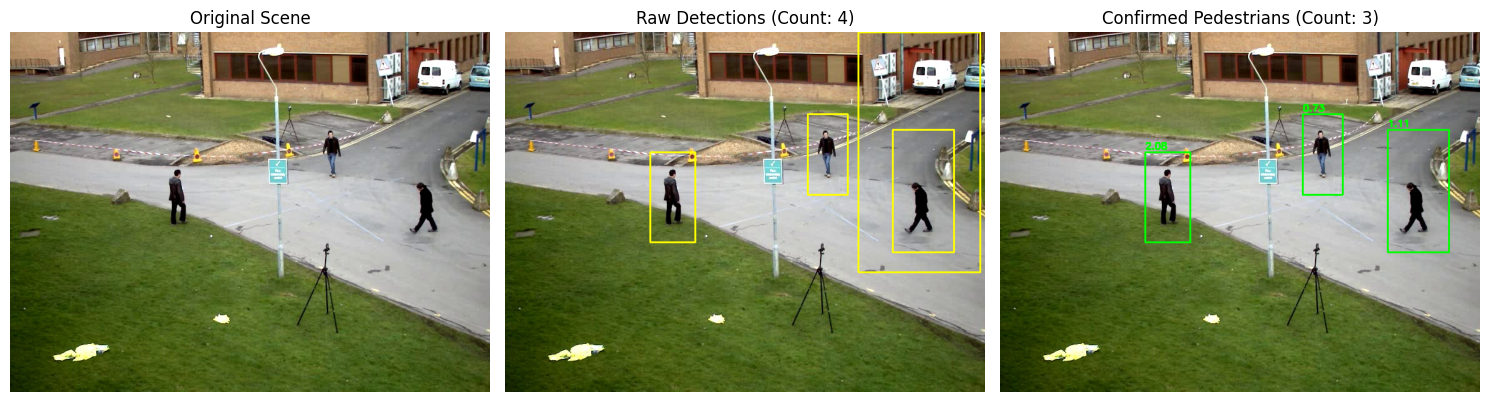

In [5]:
# Draw raw candidate boxes (yellow)
raw_img = image_rgb.copy()
for (x, y, w, h) in rects:
    cv2.rectangle(raw_img, (x, y), (x + w, y + h), (255, 255, 0), 2)

# Draw confirmed pedestrian boxes (green)
confirmed_img = image_rgb.copy()
for (x, y, w, h), w_val in zip(confirmed_boxes, confirmed_weights):
    cv2.rectangle(confirmed_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(confirmed_img, f"{w_val:.2f}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Scene')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(raw_img)
plt.title(f'Raw Detections (Count: {len(rects)})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(confirmed_img)
plt.title(f'Confirmed Pedestrians (Count: {len(confirmed_boxes)})')
plt.axis('off')

plt.tight_layout()
plt.show()

## 7. Analysis & Conclusion
1. **Raw Detections:** The raw `detectMultiScale` algorithm identified **4 candidate bounding boxes**, including 1 background false positive candidate box (`weight = 0.346`).
2. **Confidence Filtering:** Filtering by SVM confidence score (`weight >= 0.50`) eliminated the low-confidence background box, resulting in **3 confirmed pedestrian detections** matching the 3 visible persons in the scene.
3. **HOG + SVM Characteristics:** Demonstrates how classical sliding window detectors benefit from confidence thresholding and post-processing NMS to suppress weak background candidate detections.